# Prithvi EO Training and Segmentation - Clean Temporal TFRecords

This notebook stays close to `Training_and_Segmentation_Clean.ipynb` while
reading the clean train/validation TFRecords created by
`Pre_process_data_clean.ipynb`.

Every sample has four ordered slots: `[history, history, TARGET, future]`.
The target is always timestep 2, and missing context is controlled by the
explicit `temporal_mask` stored in each TFRecord. The original Prithvi FCN,
checkpoint-loading, training, evaluation, and prediction workflow is kept.


## Environment

This notebook uses a NumPy-1-compatible stack: TerraTorch 1.0,
TorchGeo 0.6.2, Rasterio 1.4.4, and Albumentations 1.4.6.

Run the next cell once when setting up the kernel. Restart the kernel after
installation, then continue from the imports cell. The imports cell also
selects Rasterio's bundled PROJ database to avoid mixed Conda/pip PROJ data.


In [ ]:
%pip install "numpy<2" "opencv-python==4.11.0.86" "opencv-python-headless==4.11.0.86" "albumentations==1.4.6" "terratorch==1.0" "torchgeo==0.6.2" "rasterio==1.4.4"


In [1]:
import importlib.util
import os
import random
import struct
from pathlib import Path

# Rasterio's wheel contains the PROJ database that matches its PROJ runtime.
_rasterio_spec = importlib.util.find_spec("rasterio")
if _rasterio_spec is not None:
    _proj_data = Path(_rasterio_spec.origin).parent / "proj_data"
    if _proj_data.exists():
        os.environ["PROJ_DATA"] = str(_proj_data)
        os.environ["PROJ_LIB"] = str(_proj_data)

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# Use TensorFlow only for TFRecord parsing; keep GPU memory for PyTorch.
try:
    tf.config.set_visible_devices([], "GPU")
    print("TensorFlow GPU disabled.")
except RuntimeError as error:
    print(
        "TensorFlow GPU was already initialized. "
        "Restart the kernel and run this cell before any TensorFlow work."
    )
    print(error)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Clean temporal TFRecords produced by Pre_process_data_clean.ipynb
TRAIN_TFRECORD = Path(
    r"D:\Data\ssm_temporal\ssm_footprint_train_clean.tfrecord"
)
VAL_TFRECORD = Path(
    r"D:\Data\ssm_temporal\ssm_footprint_val_clean.tfrecord"
)
PRETRAINED_ENCODER_PATH = Path(
    r"Y:\SPOT\2023\Asare\Prithvi_models\Mae\prithvi_mae_state_dict.pt"
)
FINETUNED_MODEL_PATH = Path("models/prithvi_state_dict_clean_new.pt")
OUTPUT_MODEL_PATH = Path("models/prithvi_state_dict_clean_new.pt")


# Data and model settings
TIMESTEPS = 4
TARGET_INDEX = 2
IMAGE_SIZE = 224
IN_CHANNELS = 6
NUM_CLASSES = 3
TRAIN_BATCH_SIZE = 2
VAL_BATCH_SIZE = 4
NUM_WORKERS = 0


# Training settings
NUM_EPOCHS = 50
LEARNING_RATE = 1.5e-5
RUN_TRAINING = True
LOAD_PRETRAINED_ENCODER = True
LOAD_FINETUNED_MODEL = True
RANDOM_CONTEXT_DROPOUT = True


assert TIMESTEPS == 4
assert TARGET_INDEX == 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PROJ data:", os.environ.get("PROJ_DATA"))
for label, path in {
    "train data": TRAIN_TFRECORD,
    "validation data": VAL_TFRECORD,
    "pretrained encoder": PRETRAINED_ENCODER_PATH,
    "fine-tuned model": FINETUNED_MODEL_PATH,
}.items():
    print(f"{label:20s}: {path} ({'found' if path.exists() else 'missing'})")

if TRAIN_TFRECORD == VAL_TFRECORD:
    raise ValueError("Training and validation TFRecord paths must differ.")


TensorFlow GPU disabled.
Device: cuda
PROJ data: c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env2\lib\site-packages\rasterio\proj_data
train data          : D:\Data\ssm_temporal\ssm_footprint_train_clean.tfrecord (found)
validation data     : D:\Data\ssm_temporal\ssm_footprint_val_clean.tfrecord (found)
pretrained encoder  : Y:\SPOT\2023\Asare\Prithvi_models\Mae\prithvi_mae_state_dict.pt (missing)
fine-tuned model    : models\prithvi_state_dict_clean_new.pt (found)


c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset

The loader follows the original notebook but consumes the clean v2 schema.
It uses the stored temporal mask instead of inferring validity from pixel
values and returns the explicit target index/year, sequence version,
background flag, frame years, split, and patch provenance.

Training can randomly hide context frames for robustness, but timestep 2 is
always retained because its image is the source of the segmentation mask.


In [4]:
def _center_pad_hw(array, target_hw):
    target_h, target_w = target_hw
    h, w = array.shape[:2]
    pad_h = max(target_h - h, 0)
    pad_w = max(target_w - w, 0)
    pad_top = pad_h // 2
    pad_left = pad_w // 2
    padding = [
        (pad_top, pad_h - pad_top),
        (pad_left, pad_w - pad_left),
    ]
    padding.extend([(0, 0)] * (array.ndim - 2))
    return np.pad(array, padding, mode="constant")


def _center_pad_cthw(image, target_hw):
    channels, timesteps, h, w = image.shape
    image_hwc = image.transpose(2, 3, 0, 1).reshape(
        h, w, channels * timesteps
    )
    image_hwc = _center_pad_hw(image_hwc, target_hw)
    padded_h, padded_w, _ = image_hwc.shape
    return image_hwc.transpose(2, 0, 1).reshape(
        channels, timesteps, padded_h, padded_w
    )


def _decode_text(value):
    return value.numpy().decode("utf-8")


class MineFootprintTFRecordDataset(Dataset):
    MEAN = np.array(
        [1087.0, 1342.0, 1433.0, 2734.0, 1958.0, 1363.0],
        dtype=np.float32,
    )
    STD = np.array(
        [2248.0, 2179.0, 2178.0, 1850.0, 1242.0, 1049.0],
        dtype=np.float32,
    )

    FEATURE_DESCRIPTION = {
        "image_raw": tf.io.FixedLenFeature([], tf.string),
        "mask_raw": tf.io.FixedLenFeature([], tf.string),
        "height": tf.io.FixedLenFeature([], tf.int64),
        "width": tf.io.FixedLenFeature([], tf.int64),
        "channels": tf.io.FixedLenFeature([], tf.int64),
        "timesteps": tf.io.FixedLenFeature([], tf.int64),
        "temporal_coords": tf.io.FixedLenFeature(
            [TIMESTEPS * 2], tf.float32
        ),
        "temporal_mask": tf.io.FixedLenFeature(
            [TIMESTEPS], tf.float32
        ),
        "location_coords": tf.io.FixedLenFeature([2], tf.float32),
        "target_index": tf.io.FixedLenFeature([], tf.int64),
        "target_year": tf.io.FixedLenFeature([], tf.int64),
        "sequence_version": tf.io.FixedLenFeature([], tf.string),
        "background_only": tf.io.FixedLenFeature([], tf.int64),
        "foreground_pixel_count": tf.io.FixedLenFeature([], tf.int64),
        "valid_frame_count": tf.io.FixedLenFeature([], tf.int64),
        "frame_years": tf.io.FixedLenFeature([TIMESTEPS], tf.int64),
        "target_group": tf.io.FixedLenFeature([], tf.string),
        "patch_id": tf.io.FixedLenFeature([], tf.string),
        "patch_row": tf.io.FixedLenFeature([], tf.int64),
        "patch_col": tf.io.FixedLenFeature([], tf.int64),
        "spatial_block": tf.io.FixedLenFeature([], tf.string),
        "split": tf.io.FixedLenFeature([], tf.string),
        "schema_version": tf.io.FixedLenFeature([], tf.string),
    }

    def __init__(
        self,
        tfrecord_path,
        transform=None,
        pad_to=(224, 224),
        expected_split=None,
    ):
        self.tfrecord_path = Path(tfrecord_path)
        if not self.tfrecord_path.exists():
            raise FileNotFoundError(
                f"TFRecord not found: {self.tfrecord_path}. "
                "Update the path in the configuration cell."
            )
        self.transform = transform
        self.pad_to = pad_to
        self.expected_split = expected_split
        self._offsets = self._scan_index()
        self._file = self.tfrecord_path.open("rb")

    def _scan_index(self):
        offsets = []
        size = self.tfrecord_path.stat().st_size
        position = 0
        with self.tfrecord_path.open("rb") as file:
            while position < size:
                file.seek(position)
                header = file.read(12)
                if len(header) != 12:
                    raise RuntimeError(
                        f"Incomplete TFRecord header at byte {position:,}"
                    )
                record_length = struct.unpack("<Q", header[:8])[0]
                offsets.append(position)
                position += 12 + record_length + 4
                if position > size:
                    raise RuntimeError(
                        f"Record at byte {offsets[-1]:,} exceeds file size"
                    )
        if position != size:
            raise RuntimeError(
                f"TFRecord ended at {position:,}; file has {size:,} bytes"
            )
        return offsets

    def _read_record(self, offset):
        self._file.seek(offset)
        header = self._file.read(12)
        if len(header) != 12:
            raise RuntimeError(f"Incomplete TFRecord header at {offset:,}")
        record_length = struct.unpack("<Q", header[:8])[0]
        data = self._file.read(record_length)
        if len(data) != record_length:
            raise RuntimeError(f"Incomplete TFRecord payload at {offset:,}")
        self._file.read(4)
        return data

    def __len__(self):
        return len(self._offsets)

    def _normalize_valid_frames(self, image, temporal_mask):
        channels = image.shape[0]
        valid = temporal_mask.astype(bool)
        normalized = np.zeros_like(image, dtype=np.float32)

        if not valid.any():
            return normalized

        if channels == len(self.MEAN):
            mean = self.MEAN.reshape(channels, 1, 1, 1)
            std = (self.STD + 1e-6).reshape(channels, 1, 1, 1)
        else:
            real = image[:, valid]
            mean = real.mean(axis=(1, 2, 3), keepdims=True)
            std = real.std(axis=(1, 2, 3), keepdims=True) + 1e-6

        normalized[:, valid] = (image[:, valid] - mean) / std
        return normalized

    def _apply_transform(self, image, mask):
        channels, timesteps, h, w = image.shape
        image_hwc = image.transpose(2, 3, 0, 1).reshape(
            h, w, channels * timesteps
        )
        augmented = self.transform(image=image_hwc, mask=mask)
        image_hwc = np.asarray(augmented["image"])
        mask = np.asarray(augmented["mask"])
        new_h, new_w, _ = image_hwc.shape
        image = image_hwc.transpose(2, 0, 1).reshape(
            channels, timesteps, new_h, new_w
        )
        return image, mask

    def __getitem__(self, index):
        serialized = self._read_record(self._offsets[index])
        example = tf.io.parse_single_example(
            serialized, self.FEATURE_DESCRIPTION
        )

        h = int(example["height"])
        w = int(example["width"])
        channels = int(example["channels"])
        timesteps = int(example["timesteps"])
        if timesteps != TIMESTEPS:
            raise ValueError(
                f"Record {index} has {timesteps} timesteps, expected {TIMESTEPS}"
            )

        image = np.frombuffer(
            example["image_raw"].numpy(), dtype=np.float32
        ).reshape(channels, timesteps, h, w)
        mask = np.frombuffer(
            example["mask_raw"].numpy(), dtype=np.uint8
        ).reshape(h, w)

        image = np.nan_to_num(
            image, nan=0.0, posinf=0.0, neginf=0.0
        )
        mask = np.nan_to_num(mask, nan=0).astype(np.uint8)
        temporal_mask = (
            example["temporal_mask"].numpy().astype(np.float32)
        )
        temporal_coords = (
            example["temporal_coords"]
            .numpy()
            .astype(np.float32)
            .reshape(timesteps, 2)
        )
        location_coords = (
            example["location_coords"].numpy().astype(np.float32)
        )
        frame_years = example["frame_years"].numpy().astype(np.int64)
        target_index = int(example["target_index"])
        target_year = int(example["target_year"])
        split = _decode_text(example["split"])
        background_only = int(example["background_only"])

        if target_index != TARGET_INDEX:
            raise ValueError(
                f"Record {index} target index is {target_index}, "
                f"expected {TARGET_INDEX}"
            )
        if temporal_mask[target_index] <= 0:
            raise ValueError(f"Record {index} masks its target frame")
        if int(frame_years[target_index]) != target_year:
            raise ValueError(
                f"Record {index} target year does not match frame years"
            )
        if self.expected_split and split != self.expected_split:
            raise ValueError(
                f"Record {index} belongs to {split}, "
                f"expected {self.expected_split}"
            )
        if background_only != int(not np.any(mask > 0)):
            raise ValueError(
                f"Record {index} background_only metadata is inconsistent"
            )

        # The record is authoritative: explicitly masked frames remain zero.
        image[:, temporal_mask <= 0] = 0.0
        image = self._normalize_valid_frames(image, temporal_mask)
        image = _center_pad_cthw(image, self.pad_to)
        mask = _center_pad_hw(mask, self.pad_to)

        if self.transform is not None:
            image, mask = self._apply_transform(image, mask)

        return {
            "image": torch.from_numpy(
                np.ascontiguousarray(image)
            ).float(),
            "temporal_coords": torch.from_numpy(
                np.ascontiguousarray(temporal_coords)
            ).float(),
            "location_coords": torch.from_numpy(
                np.ascontiguousarray(location_coords)
            ).float(),
            "temporal_mask": torch.from_numpy(
                np.ascontiguousarray(temporal_mask)
            ).float(),
            "mask": torch.from_numpy(
                np.ascontiguousarray(mask)
            ).long(),
            "target_index": torch.tensor(target_index, dtype=torch.long),
            "target_year": torch.tensor(target_year, dtype=torch.long),
            "frame_years": torch.from_numpy(
                np.ascontiguousarray(frame_years)
            ).long(),
            "background_only": torch.tensor(
                bool(background_only), dtype=torch.bool
            ),
            "foreground_pixel_count": torch.tensor(
                int(example["foreground_pixel_count"]), dtype=torch.long
            ),
            "valid_frame_count": torch.tensor(
                int(example["valid_frame_count"]), dtype=torch.long
            ),
            "sequence_version": _decode_text(
                example["sequence_version"]
            ),
            "target_group": _decode_text(example["target_group"]),
            "patch_id": _decode_text(example["patch_id"]),
            "patch_row": torch.tensor(
                int(example["patch_row"]), dtype=torch.long
            ),
            "patch_col": torch.tensor(
                int(example["patch_col"]), dtype=torch.long
            ),
            "spatial_block": _decode_text(example["spatial_block"]),
            "split": split,
            "schema_version": _decode_text(example["schema_version"]),
        }

    def close(self):
        if hasattr(self, "_file") and not self._file.closed:
            self._file.close()

    def __del__(self):
        try:
            self.close()
        except Exception:
            pass


def make_temporal_collate(timesteps=4, random_context=False):
    def collate(samples):
        tensor_keys = (
            "image",
            "temporal_coords",
            "location_coords",
            "temporal_mask",
            "mask",
            "target_index",
            "target_year",
            "frame_years",
            "background_only",
            "foreground_pixel_count",
            "valid_frame_count",
            "patch_row",
            "patch_col",
        )
        text_keys = (
            "sequence_version",
            "target_group",
            "patch_id",
            "spatial_block",
            "split",
            "schema_version",
        )
        batch = {key: [] for key in (*tensor_keys, *text_keys)}

        for sample in samples:
            image = torch.as_tensor(sample["image"]).clone()
            coords = torch.as_tensor(sample["temporal_coords"]).clone()
            temporal_mask = torch.as_tensor(
                sample["temporal_mask"]
            ).clone()
            target_index = int(sample["target_index"])

            if image.shape[1] != timesteps:
                raise ValueError(
                    f"Expected {timesteps} frames, got {image.shape[1]}"
                )
            if temporal_mask[target_index] <= 0:
                raise ValueError("Target frame cannot be masked in collate")

            if random_context:
                context = [
                    timestep
                    for timestep in range(timesteps)
                    if timestep != target_index
                    and temporal_mask[timestep] > 0
                ]
                keep_count = random.randint(0, len(context))
                keep = set(random.sample(context, keep_count))
                for timestep in context:
                    if timestep not in keep:
                        image[:, timestep] = 0
                        coords[timestep] = 0
                        temporal_mask[timestep] = 0

            batch["image"].append(image)
            batch["temporal_coords"].append(coords)
            batch["temporal_mask"].append(temporal_mask)
            for key in tensor_keys:
                if key not in {
                    "image", "temporal_coords", "temporal_mask"
                }:
                    batch[key].append(torch.as_tensor(sample[key]))
            for key in text_keys:
                batch[key].append(sample[key])

        for key in tensor_keys:
            batch[key] = torch.stack(batch[key])

        target_rows = torch.arange(len(samples))
        if not torch.all(
            batch["temporal_mask"][
                target_rows, batch["target_index"]
            ] > 0
        ):
            raise RuntimeError("Context masking removed a target frame")
        return batch

    return collate


In [5]:
# Preserved from the original notebook. Lower this if GPU memory is limited.
TRAIN_BATCH_SIZE = 4


In [7]:
train_transform = A.Compose(
    [
        A.RandomRotate90(p=0.7),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
    ]
)

train_dataset = MineFootprintTFRecordDataset(
    TRAIN_TFRECORD,
    transform=train_transform,
    pad_to=(IMAGE_SIZE, IMAGE_SIZE),
    expected_split="train",
)
val_dataset = MineFootprintTFRecordDataset(
    VAL_TFRECORD,
    transform=None,
    pad_to=(IMAGE_SIZE, IMAGE_SIZE),
    expected_split="val",
)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    collate_fn=make_temporal_collate(
        TIMESTEPS,
        random_context=RANDOM_CONTEXT_DROPOUT,
    ),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    collate_fn=make_temporal_collate(
        TIMESTEPS, random_context=False
    ),
)

print(f"Training records:   {len(train_dataset):,}")
print(f"Validation records: {len(val_dataset):,}")

first_batch = next(iter(train_loader))
for key, value in first_batch.items():
    if torch.is_tensor(value):
        print(f"{key:24s}: {tuple(value.shape)} | {value.dtype}")
    else:
        print(f"{key:24s}: {value[:3]}")

rows = torch.arange(first_batch["target_index"].shape[0])
assert torch.all(first_batch["target_index"] == TARGET_INDEX)
assert torch.all(
    first_batch["temporal_mask"][rows, first_batch["target_index"]] > 0
)
assert all(split == "train" for split in first_batch["split"])
print("Target-aware batch validation passed.")


Training records:   19,716
Validation records: 5,144
image                   : (4, 6, 4, 224, 224) | torch.float32
temporal_coords         : (4, 4, 2) | torch.float32
location_coords         : (4, 2) | torch.float32
temporal_mask           : (4, 4) | torch.float32
mask                    : (4, 224, 224) | torch.int64
target_index            : (4,) | torch.int64
target_year             : (4,) | torch.int64
frame_years             : (4, 4) | torch.int64
background_only         : (4,) | torch.bool
foreground_pixel_count  : (4,) | torch.int64
valid_frame_count       : (4,) | torch.int64
patch_row               : (4,) | torch.int64
patch_col               : (4,) | torch.int64
sequence_version        : ['sr_harmonized_cloudy', 'harmonized_cloudy', 'harmonized_cloudy']
target_group            : ['sentinel_2024-0000035328-0000023552', 'sentinel_2022-0000035328-0000023552-0000000000-0000000000', 'sentinel_2017-0000035328-0000023552']
patch_id                : ['2c782c03fa91cef72341da7c3cc6496ba

## Inspect the data

This view draws a random clean TFRecord sample, labels the fixed temporal
roles, marks the target timestep, and shows sequence/split/background
metadata with the ground-truth segmentation mask.


In [8]:
CLASS_COLORS = {
    0: [0, 0, 0],
    1: [251, 72, 196],
    2: [180, 96, 0],
    3: [255, 255, 0],
}


def mask_to_rgb(mask, colors=CLASS_COLORS):
    mask = np.asarray(mask)
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in colors.items():
        rgb[mask == class_id] = color
    return rgb


def temporal_rgb(
    image,
    dataset,
    timestep,
    valid=True,
    rgb_indices=(2, 1, 0),
    divisor=3000.0,
):
    image = torch.as_tensor(image).detach().cpu().numpy()
    if not valid:
        return np.zeros((*image.shape[-2:], 3), dtype=np.float32)
    channels = image.shape[0]
    mean = np.asarray(dataset.MEAN, dtype=np.float32).reshape(
        channels, 1, 1, 1
    )
    std = np.asarray(dataset.STD, dtype=np.float32).reshape(
        channels, 1, 1, 1
    )
    image = image * std + mean
    rgb = image[list(rgb_indices), timestep].transpose(1, 2, 0)
    return np.clip(rgb / divisor, 0.0, 1.0)


def visualize_temporal_sample(dataset, index=None, timesteps=4):
    if index is None:
        index = random.randrange(len(dataset))
    sample = dataset[index]

    image = sample["image"]
    coords = sample["temporal_coords"].cpu().numpy()
    temporal_mask = sample["temporal_mask"].cpu().numpy()
    target_index = int(sample["target_index"])
    mask = sample["mask"].cpu().numpy()
    roles = ["History 1", "History 2", "TARGET", "Future"]

    selected = list(range(min(timesteps, image.shape[1])))
    fig, axes = plt.subplots(
        1,
        len(selected) + 1,
        figsize=(3.2 * (len(selected) + 1), 3.8),
    )

    for axis, timestep in zip(axes[:-1], selected):
        valid = temporal_mask[timestep] > 0
        axis.imshow(
            temporal_rgb(
                image, dataset, timestep, valid=valid
            )
        )
        year, day = coords[timestep]
        date = (
            f"{int(year)} | DOY {int(day)}" if valid else "MASKED"
        )
        marker = " <- mask target" if timestep == target_index else ""
        axis.set_title(f"{roles[timestep]}{marker}\n{date}")
        axis.axis("off")

    axes[-1].imshow(mask_to_rgb(mask))
    axes[-1].set_title(
        f"Ground truth ({int(sample['target_year'])})\n"
        f"background={bool(sample['background_only'])}"
    )
    axes[-1].axis("off")
    fig.suptitle(
        f"Sample {index} | {sample['sequence_version']} | "
        f"{sample['split']} | {sample['patch_id'][:10]}"
    )
    plt.tight_layout()
    plt.show()
    return sample


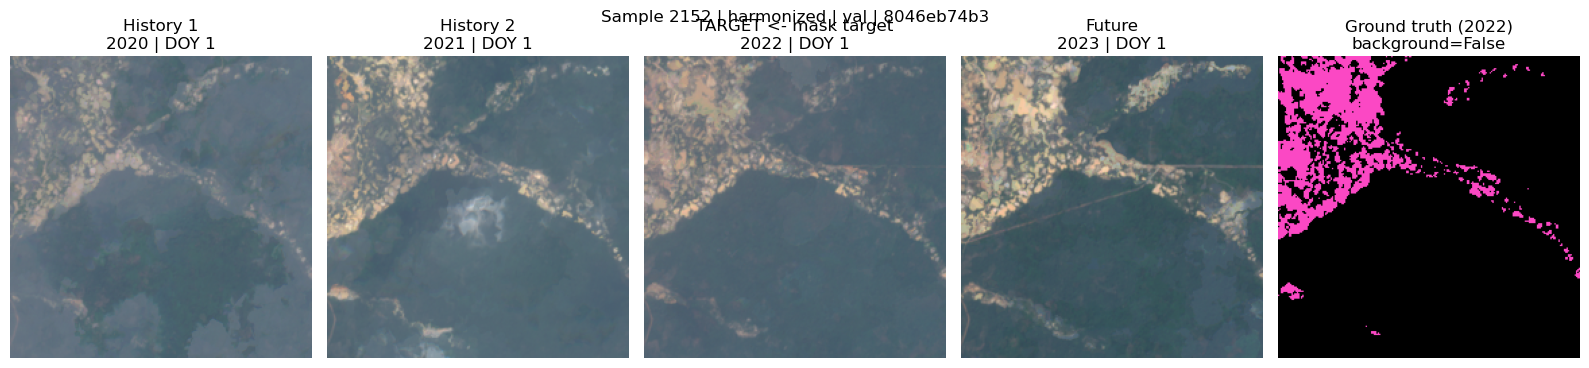

In [43]:
inspected_sample = visualize_temporal_sample(
    val_dataset, timesteps=TIMESTEPS
)


## Prithvi segmentation model

The model architecture remains the same as the original notebook. The
temporal wrapper zeros token features for frames disabled by the clean
TFRecord mask or by target-safe context dropout. Timestep 2 is always kept,
and the decoder/head produce its full-resolution segmentation map.


In [9]:
from terratorch.models.backbones.prithvi_mae import (
    PrithviViT,
    get_3d_sincos_pos_embed,
)
from terratorch.models.decoders import FCNDecoder


def set_temporal_frames(encoder, timesteps):
    patch_t = encoder.patch_embed.patch_size[0]
    if patch_t != 1:
        raise ValueError(f"Expected temporal patch size 1, got {patch_t}")

    encoder.num_frames = timesteps
    encoder.patch_embed.input_size = (
        timesteps,
        *tuple(encoder.img_size),
    )
    encoder.patch_embed.grid_size = [
        size // patch
        for size, patch in zip(
            encoder.patch_embed.input_size,
            encoder.patch_embed.patch_size,
        )
    ]

    position = get_3d_sincos_pos_embed(
        encoder.embed_dim,
        encoder.patch_embed.grid_size,
        add_cls_token=True,
    )
    position = torch.from_numpy(position).float().unsqueeze(0).to(
        encoder.cls_token.device,
        dtype=encoder.cls_token.dtype,
    )
    encoder.register_buffer("pos_embed", position, persistent=False)


class MaskedPrithviEncoder(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def forward_features(
        self,
        image,
        temporal_coords=None,
        location_coords=None,
        temporal_mask=None,
    ):
        encoder = self.encoder
        if image.ndim == 4 and encoder.num_frames == 1:
            image = image.unsqueeze(2)

        sample_shape = image.shape[-3:]
        tokens = encoder.patch_embed(image)
        position = encoder.interpolate_pos_encoding(sample_shape).to(
            tokens.device, dtype=tokens.dtype
        )
        tokens = tokens + position[:, 1:]

        if encoder.temporal_encoding and temporal_coords is not None:
            tokens_per_frame = tokens.shape[1] // encoder.num_frames
            tokens = tokens + encoder.temporal_embed_enc(
                temporal_coords, tokens_per_frame
            )
        if encoder.location_encoding and location_coords is not None:
            tokens = tokens + encoder.location_embed_enc(location_coords)

        if temporal_mask is not None:
            tokens_per_frame = tokens.shape[1] // encoder.num_frames
            token_mask = temporal_mask.to(
                tokens.device, dtype=tokens.dtype
            ).repeat_interleave(tokens_per_frame, dim=1)
            tokens = tokens * token_mask.unsqueeze(-1)

        cls_token = encoder.cls_token + position[:, :1]
        tokens = torch.cat(
            [cls_token.expand(tokens.shape[0], -1, -1), tokens],
            dim=1,
        )

        features = []
        for block in encoder.blocks:
            tokens = block(tokens)
            features.append(tokens.clone())
        features[-1] = encoder.norm(tokens)
        return features

    def prepare_features_for_image_model(self, features):
        return self.encoder.prepare_features_for_image_model(features)


class PrithviFCNSeg(nn.Module):
    def __init__(self, encoder, decoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.head = nn.Conv2d(
            decoder.out_channels, num_classes, kernel_size=1
        )

    def forward(
        self,
        image,
        temporal_coords=None,
        location_coords=None,
        temporal_mask=None,
    ):
        output_size = image.shape[-2:]
        features = self.encoder.forward_features(
            image,
            temporal_coords=temporal_coords,
            location_coords=location_coords,
            temporal_mask=temporal_mask,
        )
        feature_maps = self.encoder.prepare_features_for_image_model(
            features
        )
        logits = self.head(self.decoder(feature_maps))
        if logits.shape[-2:] != output_size:
            logits = F.interpolate(
                logits,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )
        return logits


def build_prithvi_fcn_segmentation(
    num_classes=3,
    in_channels=6,
    image_size=224,
    timesteps=4,
    patch_size=(1, 16, 16),
    embed_dim=1024,
    depth=24,
    num_heads=16,
    mlp_ratio=4.0,
    decoder_channels=256,
    decoder_num_convs=5,
):
    base_encoder = PrithviViT(
        img_size=image_size,
        patch_size=patch_size,
        num_frames=timesteps,
        in_chans=in_channels,
        embed_dim=embed_dim,
        depth=depth,
        num_heads=num_heads,
        mlp_ratio=mlp_ratio,
        coords_encoding=["time", "location"],
    )
    set_temporal_frames(base_encoder, timesteps)
    encoder = MaskedPrithviEncoder(base_encoder)
    decoder = FCNDecoder(
        embed_dim=base_encoder.out_channels,
        channels=decoder_channels,
        num_convs=decoder_num_convs,
    )
    return PrithviFCNSeg(encoder, decoder, num_classes)


In [10]:
model = build_prithvi_fcn_segmentation(
    num_classes=NUM_CLASSES,
    in_channels=IN_CHANNELS,
    image_size=IMAGE_SIZE,
    timesteps=TIMESTEPS,
).to(device)

trainable = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
total = sum(parameter.numel() for parameter in model.parameters())
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")


Trainable parameters: 312,084,227
Total parameters:     312,084,227


## Load checkpoints

Loading order is intentional:

1. Load the pretrained Prithvi encoder into the fresh model.
2. Optionally load the complete fine-tuned segmentation model.

The full fine-tuned checkpoint replaces encoder, decoder, and head
weights. Disable `LOAD_FINETUNED_MODEL` to train from the pretrained
encoder with a new decoder and head.

In [11]:
LOAD_FINETUNED_MODEL = True

In [12]:
def read_state_dict(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        checkpoint = checkpoint["state_dict"]
    return checkpoint


def load_pretrained_encoder(masked_encoder, checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    state = read_state_dict(checkpoint_path)
    encoder = masked_encoder.encoder
    target = encoder.state_dict()

    prefixes = (
        "model.backbone.encoder.",
        "backbone.encoder.",
        "model.encoder.encoder.",
        "encoder.encoder.",
        "model.encoder.",
        "encoder.",
        "module.",
    )
    compatible = {}

    for raw_key, value in state.items():
        candidates = [raw_key]
        candidates.extend(
            raw_key[len(prefix):]
            for prefix in prefixes
            if raw_key.startswith(prefix)
        )
        for key in candidates:
            if (
                key in target
                and target[key].shape == value.shape
            ):
                compatible[key] = value
                break

    if not compatible:
        raise RuntimeError(
            f"No compatible encoder weights found in {checkpoint_path}"
        )

    missing, unexpected = encoder.load_state_dict(
        compatible, strict=False
    )
    print(
        f"Loaded {len(compatible)} encoder tensors from "
        f"{checkpoint_path}"
    )
    print(
        f"Encoder missing keys: {len(missing)}; "
        f"unexpected keys: {len(unexpected)}"
    )


def load_finetuned_model(model, checkpoint_path, device):
    checkpoint_path = Path(checkpoint_path)
    state = read_state_dict(checkpoint_path)
    state = {
        key.removeprefix("module."): value
        for key, value in state.items()
    }
    model.load_state_dict(state, strict=True)
    model.to(device)
    print(f"Loaded fine-tuned model from {checkpoint_path}")


if LOAD_PRETRAINED_ENCODER:
    if PRETRAINED_ENCODER_PATH.exists():
        load_pretrained_encoder(
            model.encoder, PRETRAINED_ENCODER_PATH
        )
    else:
        print(
            "Pretrained encoder not found; skipping: "
            f"{PRETRAINED_ENCODER_PATH}"
        )

if LOAD_FINETUNED_MODEL:
    if FINETUNED_MODEL_PATH.exists():
        load_finetuned_model(
            model, FINETUNED_MODEL_PATH, device
        )
    else:
        print(
            "Fine-tuned model not found; skipping: "
            f"{FINETUNED_MODEL_PATH}"
        )


Pretrained encoder not found; skipping: Y:\SPOT\2023\Asare\Prithvi_models\Mae\prithvi_mae_state_dict.pt
Loaded fine-tuned model from models\prithvi_state_dict_clean_new.pt


## Train and evaluate

Training may randomly remove history/future context but always retains the
target at timestep 2. Validation uses all available frames and the explicit
TFRecord temporal mask. The checkpoint with the lowest validation loss is
saved to `OUTPUT_MODEL_PATH`.


In [13]:
def model_logits(model, batch, device):
    return model(
        batch["image"].to(device),
        temporal_coords=batch["temporal_coords"].to(device),
        location_coords=batch["location_coords"].to(device),
        temporal_mask=batch["temporal_mask"].to(device),
    )


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    pixels = 0
    samples = 0

    for batch in loader:
        masks = batch["mask"].to(device).long()
        logits = model_logits(model, batch, device)
        loss = criterion(logits, masks)

        batch_size = masks.shape[0]
        total_loss += loss.item() * batch_size
        samples += batch_size
        predictions = logits.argmax(dim=1)
        correct += (predictions == masks).sum().item()
        pixels += masks.numel()

    return {
        "loss": total_loss / max(samples, 1),
        "pixel_accuracy": correct / max(pixels, 1),
    }


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    checkpoint_path,
):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    best_val_loss = float("inf")
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_pixel_accuracy": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        samples = 0

        progress = tqdm(
            train_loader,
            desc=f"Epoch {epoch}/{epochs}",
            unit="batch",
        )
        for batch in progress:
            masks = batch["mask"].to(device).long()
            optimizer.zero_grad(set_to_none=True)
            logits = model_logits(model, batch, device)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            batch_size = masks.shape[0]
            running_loss += loss.item() * batch_size
            samples += batch_size
            progress.set_postfix(
                train_loss=running_loss / samples
            )

        train_loss = running_loss / max(samples, 1)
        validation = evaluate(
            model, val_loader, criterion, device
        )
        history["train_loss"].append(train_loss)
        history["val_loss"].append(validation["loss"])
        history["val_pixel_accuracy"].append(
            validation["pixel_accuracy"]
        )

        if validation["loss"] < best_val_loss:
            best_val_loss = validation["loss"]
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Epoch {epoch:02d}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={validation['loss']:.4f}, "
            f"val_acc={validation['pixel_accuracy']:.2%}"
        )

    load_finetuned_model(model, checkpoint_path, device)
    return history


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=LEARNING_RATE
)

history = None
if RUN_TRAINING:
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=NUM_EPOCHS,
        checkpoint_path=OUTPUT_MODEL_PATH,
    )

    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


Epoch 1/50:  28%|██▊       | 1381/4929 [21:53<57:46,  1.02batch/s, train_loss=0.0127]  

## Visualize input, ground truth, and prediction

The prediction view reads `target_index` and `target_year` from the TFRecord.
Pass one-based positions through `masked_timesteps` to perform temporal
ablation. For example, `[1, 2, 4]` zeros those images, coordinates, and mask
entries before inference, leaving only timestep 3. Frames already missing in
the TFRecord remain masked.


In [269]:
# Save the final model state dict without overwriting the original notebook.
OUTPUT_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), OUTPUT_MODEL_PATH)
print(f"Final model state dict saved to {OUTPUT_MODEL_PATH}")


Final model state dict saved to models\prithvi_state_dict_clean_new.pt


In [76]:
@torch.no_grad()
def visualize_prediction(
    model,
    dataset,
    device,
    timesteps=4,
    index=None,
    masked_timesteps=None,
    show=True,
):
    if index is None:
        index = random.randrange(len(dataset))

    sample = dataset[index]
    batch = make_temporal_collate(
        timesteps, random_context=False
    )([sample])

    if masked_timesteps is None:
        masked_timesteps = []
    else:
        masked_timesteps = list(masked_timesteps)
    if any(
        not isinstance(value, (int, np.integer))
        for value in masked_timesteps
    ):
        raise TypeError(
            "masked_timesteps must contain one-based integer positions"
        )
    masked_timesteps = sorted(set(map(int, masked_timesteps)))
    invalid = [
        value
        for value in masked_timesteps
        if value < 1 or value > timesteps
    ]
    if invalid:
        raise ValueError(
            f"masked_timesteps must be between 1 and {timesteps}; "
            f"received {invalid}"
        )

    # User-facing timestep numbers are one-based; tensors are zero-based.
    masked_indices = [value - 1 for value in masked_timesteps]
    source_temporal_mask = batch["temporal_mask"][0].clone()
    source_temporal_coords = batch["temporal_coords"][0].clone()
    for timestep in masked_indices:
        batch["image"][:, :, timestep] = 0
        batch["temporal_coords"][:, timestep] = 0
        batch["temporal_mask"][:, timestep] = 0

    active_timesteps = [
        timestep + 1
        for timestep in range(timesteps)
        if batch["temporal_mask"][0, timestep] > 0
    ]
    if not active_timesteps:
        raise ValueError(
            "The requested mask removes every available timestep."
        )

    target_timestep = int(batch["target_index"][0])
    if target_timestep in masked_indices:
        print(
            "Warning: the target image is manually masked; the model will "
            "predict the target mask from context only."
        )
    print(
        "Manually masked timesteps:", masked_timesteps or "none",
        "| Active timesteps:", active_timesteps,
    )

    model.eval()
    logits = model_logits(model, batch, device)
    prediction = logits.argmax(dim=1)[0].cpu().numpy()
    ground_truth = batch["mask"][0].cpu().numpy()

    # Per-sample IoU. Classes absent from both masks are excluded from mIoU.
    class_iou = {}
    for class_id in range(logits.shape[1]):
        predicted_class = prediction == class_id
        target_class = ground_truth == class_id
        intersection = np.logical_and(
            predicted_class, target_class
        ).sum(dtype=np.int64)
        union = np.logical_or(
            predicted_class, target_class
        ).sum(dtype=np.int64)
        class_iou[class_id] = (
            float(intersection / union) if union else float("nan")
        )

    present_class_iou = [
        value for value in class_iou.values() if not np.isnan(value)
    ]
    mean_iou = (
        float(np.mean(present_class_iou))
        if present_class_iou
        else float("nan")
    )

    # Treat every non-background class as foreground for footprint IoU.
    foreground_prediction = prediction > 0
    foreground_target = ground_truth > 0
    foreground_intersection = np.logical_and(
        foreground_prediction, foreground_target
    ).sum(dtype=np.int64)
    foreground_union = np.logical_or(
        foreground_prediction, foreground_target
    ).sum(dtype=np.int64)
    foreground_iou = (
        float(foreground_intersection / foreground_union)
        if foreground_union
        else 1.0
    )
    class_iou_label = {
        class_id: (
            f"{value:.3f}" if not np.isnan(value) else "absent"
        )
        for class_id, value in class_iou.items()
    }
    print(
        f"mIoU: {mean_iou:.3f} | foreground IoU: "
        f"{foreground_iou:.3f} | class IoU: {class_iou_label}"
    )

    target_year = int(batch["target_year"][0])
    temporal_mask = batch["temporal_mask"][0]
    roles = ["history_1", "history_2", "target", "future"]

    input_frames = []
    for timestep in range(timesteps):
        source_valid = bool(source_temporal_mask[timestep] > 0)
        manually_masked = timestep in masked_indices
        valid = bool(temporal_mask[timestep] > 0)
        coords = source_temporal_coords[timestep]
        frame_year = int(coords[0].item()) if source_valid else 0
        frame_day = int(coords[1].item()) if source_valid else 0
        input_frames.append(
            {
                "timestep": timestep,
                "position": timestep + 1,
                "role": roles[timestep],
                "is_target": timestep == target_timestep,
                "source_valid": source_valid,
                "manually_masked": manually_masked,
                "valid": valid,
                "year": frame_year,
                "day": frame_day,
                "rgb": temporal_rgb(
                    batch["image"][0],
                    dataset,
                    timestep,
                    valid=valid,
                ),
            }
        )

    result = {
        "index": int(index),
        "target_year": target_year,
        "target_timestep": target_timestep,
        "target_position": target_timestep + 1,
        "masked_timesteps": masked_timesteps,
        "active_timesteps": active_timesteps,
        "sequence_version": sample["sequence_version"],
        "patch_id": sample["patch_id"],
        "inputs": input_frames,
        "ground_truth": ground_truth.astype(np.uint8),
        "prediction": prediction.astype(np.uint8),
        "iou": mean_iou,
        "mean_iou": mean_iou,
        "foreground_iou": foreground_iou,
        "class_iou": class_iou,
    }

    if show:
        columns = len(input_frames) + 2
        figure, axes = plt.subplots(
            1,
            columns,
            figsize=(3.2 * columns, 4.5),
            squeeze=False,
        )
        axes = axes[0]

        for axis, frame in zip(axes[:-2], input_frames):
            axis.imshow(frame["rgb"])
            if frame["manually_masked"]:
                date = (
                    f"MANUALLY MASKED\n{frame['year']} | DOY {frame['day']}"
                    if frame["source_valid"]
                    else "MANUALLY MASKED\n(source already missing)"
                )
            elif frame["source_valid"]:
                date = f"{frame['year']} | DOY {frame['day']}"
            else:
                date = "MISSING IN TFRECORD"
            marker = (
                " <- segmentation target" if frame["is_target"] else ""
            )
            axis.set_title(
                f"t{frame['position']} | "
                f"{frame['role'].replace('_', ' ').title()}{marker}\n"
                f"{date}"
            )

        axes[-2].imshow(mask_to_rgb(ground_truth))
        axes[-2].set_title(f"Ground truth ({target_year})")
        axes[-1].imshow(mask_to_rgb(prediction))
        axes[-1].set_title(
            f"Prediction ({target_year})\n"
            f"mIoU={mean_iou:.3f} | fg IoU={foreground_iou:.3f}"
        )

        for axis in axes:
            axis.axis("off")
        masked_label = (
            ", ".join(f"t{value}" for value in masked_timesteps)
            or "none"
        )
        figure.suptitle(
            f"Validation sample {index} | "
            f"{sample['sequence_version']} | {sample['patch_id'][:10]} | "
            f"manually masked: {masked_label}"
        )
        plt.tight_layout()
        plt.show()

    return result


In [77]:
from PIL import Image


def _rgb_float_to_uint8(rgb):
    rgb = np.asarray(rgb, dtype=np.float32)
    return (np.clip(rgb, 0.0, 1.0) * 255).round().astype(np.uint8)


def _save_uint8_png(array, path):
    Image.fromarray(np.asarray(array, dtype=np.uint8)).save(path)


def save_prediction_sample(result, output_root=Path("predictions")):
    sample_dir = Path(output_root) / (
        f"{result['index']}_{result['target_year']}"
    )
    inputs_dir = sample_dir / "inputs"
    mask_dir = sample_dir / "mask"
    inputs_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    saved_inputs = []
    used_names = set()
    for frame in result["inputs"]:
        name = f"{frame['year']}.png"
        if name in used_names:
            name = (
                f"{frame['year']}_doy{frame['day']}"
                f"_t{frame['timestep']}.png"
            )
        used_names.add(name)

        path = inputs_dir / name
        _save_uint8_png(_rgb_float_to_uint8(frame["rgb"]), path)
        saved_inputs.append(path)

    target_year = result["target_year"]
    gt_path = mask_dir / f"{target_year}_gt.png"
    pred_path = mask_dir / f"{target_year}_pred.png"
    _save_uint8_png(result["ground_truth"], gt_path)
    _save_uint8_png(result["prediction"], pred_path)

    saved = {
        "sample_dir": sample_dir,
        "inputs": saved_inputs,
        "ground_truth": gt_path,
        "prediction": pred_path,
    }
    print(f"Saved prediction sample to {sample_dir}")
    return saved


Manually masked timesteps: none | Active timesteps: [1, 2, 3]
mIoU: 0.779 | foreground IoU: 0.560 | class IoU: {0: '0.998', 1: 'absent', 2: '0.560'}


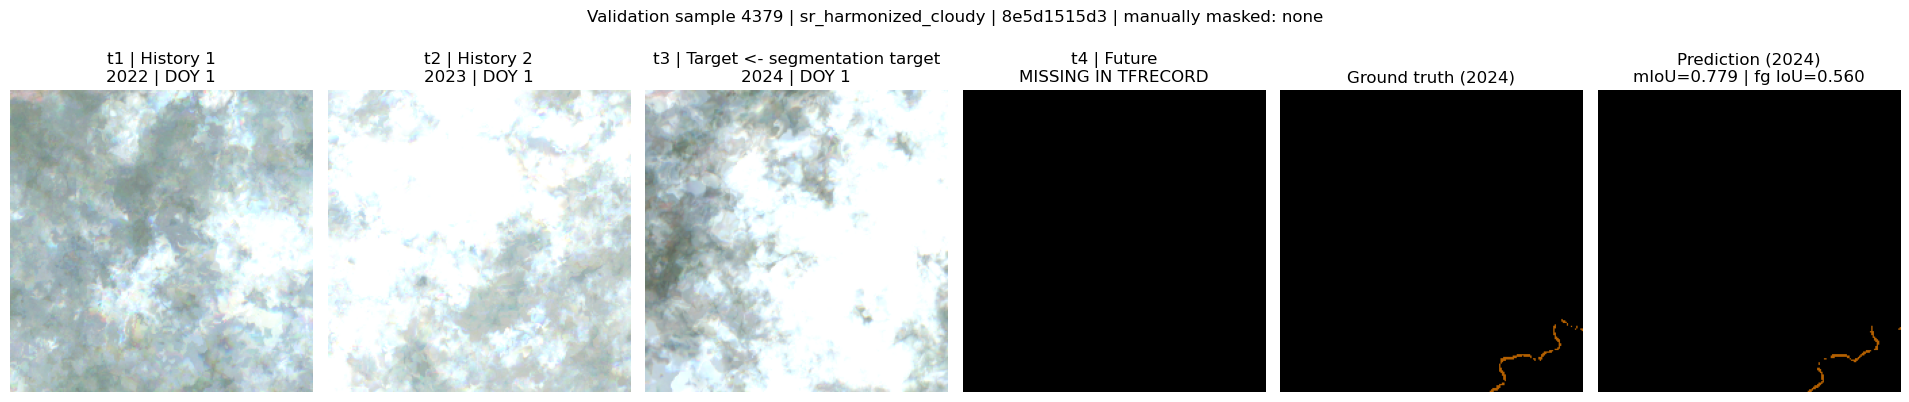

In [356]:
SAMPLE_INDEX = None  # Set to an integer, for example 1022, to revisit a sample.
#SAMPLE_INDEX = 1413  # Example index for visualization and saving.
MASKED_TIMESTEPS = []  # One-based; use [] to keep all available frames.
#MASKED_TIMESTEPS = [1, 2, 4]
# MASKED_TIMESTEPS = [1, 2, 4]  # target only
#MASKED_TIMESTEPS = [3]        # context only
# MASKED_TIMESTEPS = [1, 2]     # target + future
#MASKED_TIMESTEPS = [4]        # history + target
prediction_sample = visualize_prediction(
    model,
    val_dataset,
    device=device,
    timesteps=TIMESTEPS,
    index=SAMPLE_INDEX,
    masked_timesteps=MASKED_TIMESTEPS,
)

Manually masked timesteps: [3] | Active timesteps: [1, 2]
mIoU: 0.745 | foreground IoU: 0.493 | class IoU: {0: '0.998', 1: 'absent', 2: '0.493'}


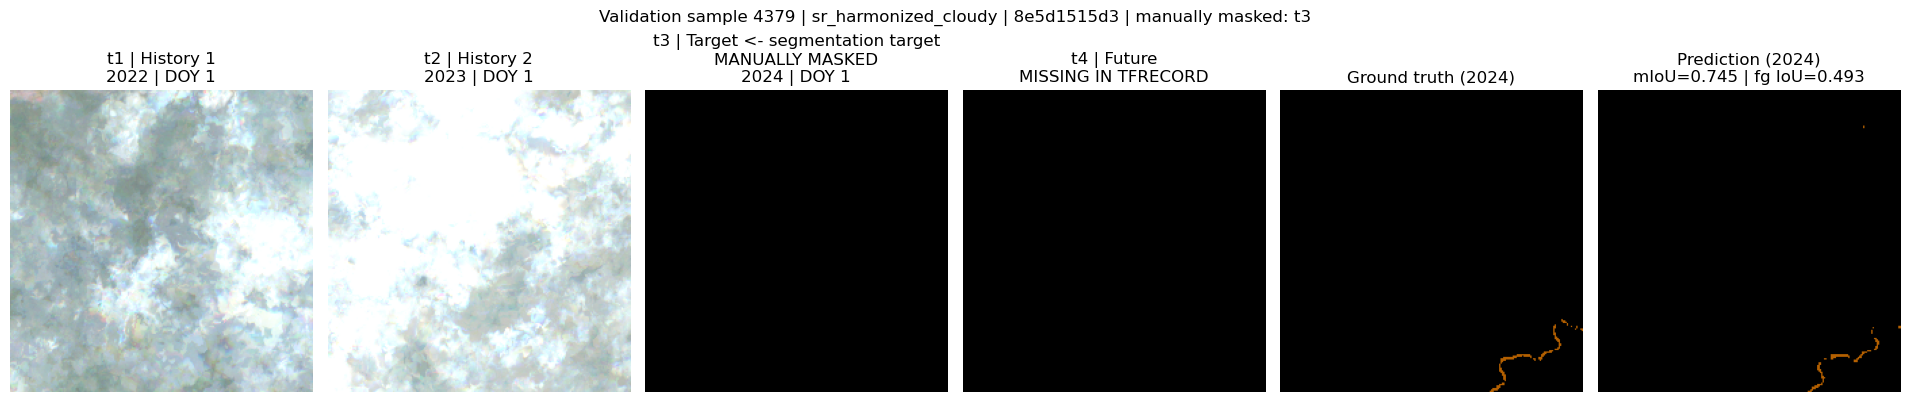

In [358]:
#SAMPLE_INDEX = None  # Set to an integer, for example 1022, to revisit a sample.
SAMPLE_INDEX = 4379  # Example index for visualization and saving.
MASKED_TIMESTEPS = []  # One-based; use [] to keep all available frames.
MASKED_TIMESTEPS = [1, 2, 4]  # target only
MASKED_TIMESTEPS = [3]        # context only
#MASKED_TIMESTEPS = [1, 2]     # target + future
#MASKED_TIMESTEPS = [4]        # history + target
prediction_sample = visualize_prediction(
    model,
    val_dataset,
    device=device,
    timesteps=TIMESTEPS,
    index=SAMPLE_INDEX,
    masked_timesteps=MASKED_TIMESTEPS,
)

In [ ]:
saved_prediction_sample = save_prediction_sample(prediction_sample)
saved_prediction_sample

## Visualize Prithvi attention maps

This section is adapted from
`Training_and_Segmentation_Prithvi_600M_TL_Temporal_Masking_Clean.ipynb`.
It supports any transformer layer, a single head or the mean of all
heads, and either CLS-to-patch or mean patch-to-patch attention.

`masked_timesteps` uses the same one-based convention as
`visualize_prediction`: `[1, 2, 4]` leaves only timestep 3 active.
Existing TFRecord masks remain authoritative. Set `masked=True` only
when an additional random target-safe context mask is desired.


In [95]:
# Visualize spatial self-attention from any Prithvi transformer layer.
def _prithvi_attention_weights(attention_module, tokens):
    if not hasattr(attention_module, "qkv"):
        raise TypeError(
            "Expected a TerraTorch/timm attention module with a qkv "
            "projection."
        )

    batch_size, token_count, embedding_dim = tokens.shape
    num_heads = attention_module.num_heads
    head_dim = embedding_dim // num_heads
    qkv = attention_module.qkv(tokens).reshape(
        batch_size, token_count, 3, num_heads, head_dim
    ).permute(2, 0, 3, 1, 4)
    queries, keys, _ = qkv.unbind(0)

    query_norm = getattr(attention_module, "q_norm", None)
    key_norm = getattr(attention_module, "k_norm", None)
    if query_norm is not None:
        queries = query_norm(queries)
    if key_norm is not None:
        keys = key_norm(keys)

    scale = getattr(attention_module, "scale", head_dim ** -0.5)
    scores = (
        queries.float() * scale
    ) @ keys.float().transpose(-2, -1)
    return scores.softmax(dim=-1)


def _normalize_attention_masked_timesteps(
    masked_timesteps, timesteps
):
    if masked_timesteps is None:
        return []
    values = list(masked_timesteps)
    if any(
        not isinstance(value, (int, np.integer))
        for value in values
    ):
        raise TypeError(
            "masked_timesteps must contain one-based integer positions"
        )
    values = sorted(set(map(int, values)))
    invalid = [
        value for value in values
        if value < 1 or value > timesteps
    ]
    if invalid:
        raise ValueError(
            f"masked_timesteps must be between 1 and {timesteps}; "
            f"received {invalid}"
        )
    return values


@torch.no_grad()
def visualize_attention_map(
    model,
    dataset,
    device,
    timesteps=4,
    index=None,
    layer=-1,
    head=None,
    query="cls",
    masked=False,
    masked_timesteps=None,
    alpha=0.55,
    cmap="inferno",
    show=True,
):
    """Overlay Prithvi self-attention on every temporal RGB frame.

    Args:
        layer: Transformer layer index; -1 selects the final layer.
        head: Attention-head index, or None to average all heads.
        query: "cls" for CLS-to-patch attention or "patch_mean"
            to average attention from all valid patch-query tokens.
        masked: Apply random target-safe context dropout first.
        masked_timesteps: One-based temporal positions to remove
            deterministically before inference.
        show: Display the figure when True.

    Returns a dictionary containing raw and normalized attention maps,
    temporal attention mass, the prediction, and sample metadata.
    """
    if query not in {"cls", "patch_mean"}:
        raise ValueError("query must be 'cls' or 'patch_mean'.")
    if index is None:
        index = random.randrange(len(dataset))

    manual_mask = _normalize_attention_masked_timesteps(
        masked_timesteps, timesteps
    )
    manual_indices = [value - 1 for value in manual_mask]

    sample = dataset[index]
    source_temporal_mask = torch.as_tensor(
        sample["temporal_mask"]
    ).clone()
    source_temporal_coords = torch.as_tensor(
        sample["temporal_coords"]
    ).clone()
    batch = make_temporal_collate(
        timesteps=timesteps,
        random_context=masked,
    )([sample])
    context_temporal_mask = batch["temporal_mask"][0].clone()

    for timestep in manual_indices:
        batch["image"][:, :, timestep] = 0
        batch["temporal_coords"][:, timestep] = 0
        batch["temporal_mask"][:, timestep] = 0

    active_timesteps = [
        timestep + 1
        for timestep in range(timesteps)
        if batch["temporal_mask"][0, timestep] > 0
    ]
    if not active_timesteps:
        raise ValueError(
            "The requested mask removes every available timestep."
        )

    base_encoder = model.encoder.encoder
    number_of_layers = len(base_encoder.blocks)
    layer_index = (
        layer if layer >= 0 else number_of_layers + layer
    )
    if not 0 <= layer_index < number_of_layers:
        raise IndexError(
            f"layer must be in "
            f"[{-number_of_layers}, {number_of_layers - 1}]"
        )

    attention_module = base_encoder.blocks[layer_index].attn
    if (
        head is not None
        and not 0 <= head < attention_module.num_heads
    ):
        raise IndexError(
            f"head must be in "
            f"[0, {attention_module.num_heads - 1}]"
        )

    captured = {}

    def capture_attention_input(_module, inputs):
        captured["tokens"] = inputs[0].detach()

    was_training = model.training
    model.eval()
    hook = attention_module.register_forward_pre_hook(
        capture_attention_input
    )
    try:
        logits = model_logits(model, batch, device)
    finally:
        hook.remove()
        model.train(was_training)

    if "tokens" not in captured:
        raise RuntimeError(
            "The selected attention layer was not executed."
        )

    attention = _prithvi_attention_weights(
        attention_module, captured["tokens"]
    )
    if head is None:
        attention = attention.mean(dim=1)
    else:
        attention = attention[:, head]

    image = batch["image"]
    patch_size = base_encoder.patch_embed.patch_size
    if isinstance(patch_size, int):
        patch_height = patch_width = patch_size
    else:
        patch_height, patch_width = patch_size[-2:]
    grid_height = image.shape[-2] // patch_height
    grid_width = image.shape[-1] // patch_width
    patches_per_frame = grid_height * grid_width
    patch_token_count = attention.shape[-1] - 1
    if patch_token_count % patches_per_frame != 0:
        raise RuntimeError(
            "Cannot reshape attention tokens into the Prithvi patch "
            "grid."
        )
    token_frames = patch_token_count // patches_per_frame

    # Keep mask and attention on the same device (CPU or CUDA).
    temporal_mask = batch["temporal_mask"][
        0, :token_frames
    ].to(device=attention.device, dtype=torch.bool)
    if query == "cls":
        patch_attention = attention[0, 0, 1:]
    else:
        valid_queries = temporal_mask.repeat_interleave(
            patches_per_frame
        )
        patch_to_patch = attention[0, 1:, 1:]
        if not valid_queries.any():
            raise RuntimeError(
                "No valid temporal frames are available."
            )
        patch_attention = patch_to_patch[
            valid_queries
        ].mean(dim=0)

    raw_maps = patch_attention.reshape(
        token_frames, grid_height, grid_width
    )
    raw_maps = raw_maps * temporal_mask[:, None, None]
    temporal_attention = raw_maps.sum(dim=(1, 2))
    maximum = raw_maps.max().clamp_min(
        torch.finfo(raw_maps.dtype).eps
    )
    normalized_maps = raw_maps / maximum
    display_maps = F.interpolate(
        normalized_maps[:, None],
        size=image.shape[-2:],
        mode="bilinear",
        align_corners=False,
    )[:, 0].cpu().numpy()

    roles = ["History 1", "History 2", "TARGET", "Future"]
    if show:
        figure, axes = plt.subplots(
            2,
            token_frames,
            figsize=(4 * token_frames, 7),
            squeeze=False,
        )
        for timestep in range(token_frames):
            source_valid = bool(
                source_temporal_mask[timestep] > 0
            )
            context_valid = bool(
                context_temporal_mask[timestep] > 0
            )
            manually_masked = timestep in manual_indices
            is_valid = bool(temporal_mask[timestep])

            if is_valid:
                rgb = temporal_rgb(
                    image[0],
                    dataset,
                    timestep,
                    valid=True,
                )
            else:
                rgb = np.zeros(
                    (image.shape[-2], image.shape[-1], 3),
                    dtype=np.float32,
                )

            coords = source_temporal_coords[timestep]
            year = int(coords[0].item()) if source_valid else 0
            day = int(coords[1].item()) if source_valid else 0
            if manually_masked:
                status = (
                    f"MANUALLY MASKED\n{year} | DOY {day}"
                    if source_valid
                    else "MANUALLY MASKED\n(source missing)"
                )
            elif source_valid and not context_valid:
                status = f"CONTEXT MASKED\n{year} | DOY {day}"
            elif source_valid:
                status = f"{year} | DOY {day}"
            else:
                status = "MISSING IN TFRECORD"

            axes[0, timestep].imshow(rgb)
            axes[0, timestep].set_title(
                f"t{timestep + 1} | {roles[timestep]}\n{status}"
            )
            axes[1, timestep].imshow(rgb)
            axes[1, timestep].imshow(
                display_maps[timestep],
                cmap=cmap,
                vmin=0.0,
                vmax=1.0,
                alpha=alpha,
            )
            mass = float(temporal_attention[timestep].cpu())
            axes[1, timestep].set_title(
                f"Attention overlay\nmass={mass:.3f}"
            )
            axes[0, timestep].axis("off")
            axes[1, timestep].axis("off")

        head_label = (
            "mean of all heads"
            if head is None
            else f"head {head}"
        )
        masked_label = (
            ", ".join(f"t{value}" for value in manual_mask)
            or "none"
        )
        figure.suptitle(
            f"Prithvi layer {layer_index} - {head_label} - "
            f"{query} query (sample {index}) | "
            f"manually masked: {masked_label}"
        )
        plt.tight_layout()
        plt.show()

    return {
        "index": int(index),
        "layer": int(layer_index),
        "head": head,
        "query": query,
        "target_index": int(sample["target_index"]),
        "target_position": int(sample["target_index"]) + 1,
        "target_year": int(sample["target_year"]),
        "sequence_version": sample["sequence_version"],
        "patch_id": sample["patch_id"],
        "masked_timesteps": manual_mask,
        "active_timesteps": active_timesteps,
        "temporal_mask": temporal_mask.cpu().numpy(),
        "raw_attention": raw_maps.cpu().numpy(),
        "normalized_attention": display_maps,
        "temporal_attention": temporal_attention.cpu().numpy(),
        "prediction": logits.argmax(dim=1)[0].cpu().numpy(),
    }


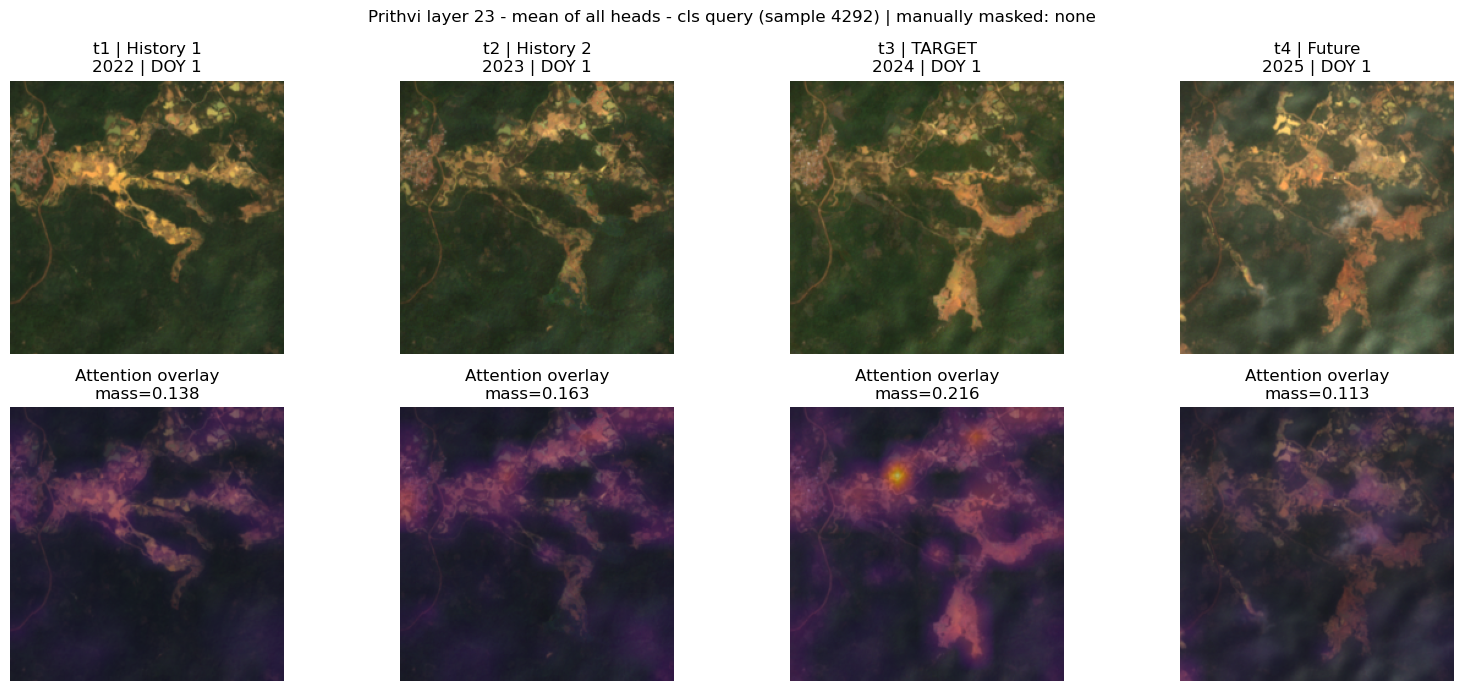

In [279]:
ATTENTION_SAMPLE_INDEX = SAMPLE_INDEX
ATTENTION_MASKED_TIMESTEPS = [1, 2, 4]
ATTENTION_MASKED_TIMESTEPS = None  # Use [] to keep all available frames.

attention_result = visualize_attention_map(
    model,
    val_dataset,
    device,
    timesteps=TIMESTEPS,
    index=ATTENTION_SAMPLE_INDEX,
    layer=-1,
    head=None,
    query="cls",
    masked=False,
    masked_timesteps=ATTENTION_MASKED_TIMESTEPS,
)


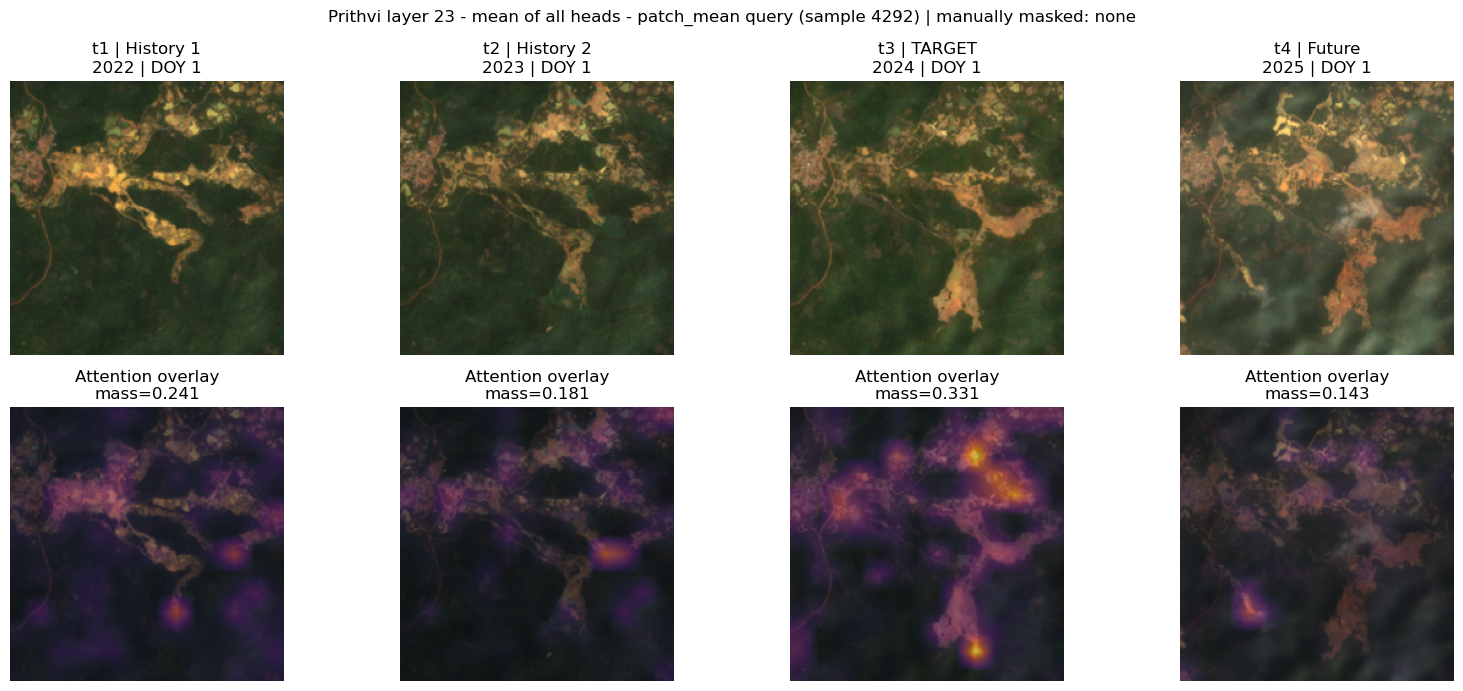

In [283]:
ATTENTION_SAMPLE_INDEX = SAMPLE_INDEX
ATTENTION_MASKED_TIMESTEPS = [1, 2, 4]
ATTENTION_MASKED_TIMESTEPS = None  # Use [] to keep all available frames.

attention_result = visualize_attention_map(
    model,
    val_dataset,
    device,
    timesteps=TIMESTEPS,
    index=ATTENTION_SAMPLE_INDEX,
    layer=-1,
    head=None,
    query="patch_mean",
    masked=False,
    masked_timesteps=ATTENTION_MASKED_TIMESTEPS,
)